# (노트) 클래스2022(4)

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- categories: [파이썬]

## 클래스공부 6단계

`-` 클래스는 밈의 일종 
- 복제 + 변형이 특징 
- 슉슈슈숙처럼 복제틀자체가 변화하는 경우도 많음 

`-` 복제틀자체가 변화: 베이스클래스 -> 서브클래스로의 변화

### 인사관리 예제

`-` 아래와 같은 클래스를 만들자. 
- 이름, 직급, 연봉에 대한 정보가 있다. 
- 연봉을 올리는 메소드가 있다. 

In [125]:
class Person:employee
    def __init__(self,name,job=None,pay=0):
        self.name=name
        self.job=job
        self.pay=pay
    def giveraise(self,percent): 
        self.pay = self.pay*(1+percent)
    def _repr_html_(self): 
        html_str = """
        이름: {} <br/>
        직업: {} <br/>
        연봉: {}
        """.format(self.name,self.job,self.pay)
        return html_str

`-` 확인

In [126]:
iu = Person('iu',job='dev',pay=5000)
hd = Person('hodong', job='mgr', pay=8000)
hynn = Person('hynn', job='dev', pay=4000)

In [127]:
iu

In [128]:
hynn

In [129]:
hd

In [130]:
iu.giveraise(0.1)
iu

In [131]:
hynn.giveraise(0.1)
hynn

In [132]:
hd.giveraise(0.1) # 매니저는 10%의 기본연봉상승에 10%보너스상승이 존재함. 
hd

`-` 회사에서 모든 직원의 연봉을 10%씩 올린다.

In [133]:
for i in [iu,hynn,hd]:
    i.giveraise(0.1)

In [134]:
iu

In [135]:
hynn

In [136]:
hd

`-` 매니저는 Person과 동일한데 연봉상승법만 약간 다르다고 하자. (기본상승분이외에 10%의 보너스상승분이 있음)

(구현1)

In [137]:
iu = Person('iu',job='dev',pay=5000)
hd = Person('hodong', job='mgr', pay=8000)
hynn = Person('hynn', job='dev', pay=4000)

In [138]:
for i in [iu,hynn,hd]:
    if i.job=='mgr': 
        i.giveraise(0.1+0.1)
    else:
        i.giveraise(0.1)

In [139]:
iu

In [140]:
hynn

In [141]:
hd

(구현2) 새로운 클래스를 만들자 그냥

In [168]:
class Manager:
    def __init__(self,name,job=None,pay=0):
        self.name=name
        self.job=job
        self.pay=pay
    def giveraise(self,percent): 
        self.pay = self.pay*(1+percent+0.1)
    def _repr_html_(self): 
        html_str = """
        이름: {} <br/>
        직업: {} <br/>
        연봉: {}
        """.format(self.name,self.job,self.pay)
        return html_str

In [169]:
iu = Person('iu',job='dev',pay=5000)
hd = Manager('hodong', job='mgr', pay=8000)
hynn = Person('hynn', job='dev', pay=4000)

In [170]:
for i in [iu,hynn,hd]:
    i.giveraise(0.1)

In [171]:
iu

In [172]:
hynn

In [173]:
hd

`-` 구현3: 새로운 클래스를 만들고 보니 일부를 제외하고 Person과 비슷함 -> Person을 이용하여 만들자.

In [174]:
class Person:
    def __init__(self,name,job=None,pay=0):
        self.name=name
        self.job=job
        self.pay=pay
    def giveraise(self,percent): 
        self.pay = self.pay*(1+percent)
    def _repr_html_(self): 
        html_str = """
        이름: {} <br/>
        직업: {} <br/>
        연봉: {}
        """.format(self.name,self.job,self.pay)
        return html_str

In [175]:
class Manager(Person): # 클래스를 만들때 Person을 입력으로 넣음. 
    pass

In [176]:
hd=Manager('hodong',pay=8000)

In [177]:
hd.giveraise(0.2)

In [178]:
hd

- 이렇게 하면 Manager는 Person과 완전히 같은 역할을 하는 클래스

In [179]:
class Manager(Person): # 클래스를 만들때 Person을 입력으로 넣음. 
    def giveraise(self,percent): 
        self.pay = self.pay*(1+percent+0.1)

- 이것은 Manager가 Person과 완전히 같은 역할을 하지만 연봉상승에 대한 부분만 변경한 것임 

In [180]:
iu = Person('iu',job='dev',pay=5000)
hd = Manager('hodong', job='mgr', pay=8000)
hynn = Person('hynn', job='dev', pay=4000)

In [181]:
for i in [iu,hynn,hd]:
    i.giveraise(0.1)

In [182]:
iu

In [184]:
hd

In [185]:
hynn

`-` 요약: 이미 만들어진 클래스에서 일부기능을 변경 혹은 추가하고 싶다면 클래스를 상속하라!

#### 리스트상속

`-` list와 비슷한데 멤버들의 빈도가 계산되는 메소드를 포함하는 새로운 나만의 list를 만들고 싶다고 하자. 

In [91]:
lst = ['a','b','a','c','b','a','d']

In [92]:
lst

['a', 'b', 'a', 'c', 'b', 'a', 'd']

`-` 아래와 같은 딕셔너리를 만들고 싶다. 

In [93]:
freq = {'a':3, 'b':2, 'c':1, 'd':1}
freq

{'a': 3, 'b': 2, 'c': 1, 'd': 1}

`-` 구현

(시도1) 반쯤성공?

In [97]:
freq = {'a':0, 'b':0, 'c':0, 'd':0} 

In [98]:
for item in lst: 
    freq[item] = freq[item] + 1 

In [99]:
freq

{'a': 3, 'b': 2, 'c': 1, 'd': 1}

(시도2) 실패

In [101]:
freq = dict() 

In [102]:
for item in lst: 
    freq[item] = freq[item] + 1 

KeyError: 'a'

에러이유? `freq['a']`를 호출할 수 없다 -> `freq.get('a',0)` 이용

In [106]:
freq.get('a') # freq['a']에 해당하는 자료가 없어도 에러가 나지 않음. 

In [107]:
freq.get('a',0) # freq['a']에 해당하는 자료가 없어도 에러가 나지 않음 + 0을 리턴

0

In [111]:
freq.get?

Signature: freq.get(key, default=None, /)
Docstring: Return the value for key if key is in the dictionary, else default.
Type:      builtin_function_or_method


- key에 대응하는 값이 있으면 그 값을 리턴하고 없으면 default를 리턴

(시도3) 성공

In [112]:
freq = dict()
for item in lst: 
    freq[item] = freq.get(item,0) + 1 

In [113]:
freq

{'a': 3, 'b': 2, 'c': 1, 'd': 1}

`-` 이것을 list의 기본기능으로 넣고 싶음 

In [123]:
class L(list):
    def frequency(self):
        freq = dict()
        for item in self: 
            freq[item] = freq.get(item,0) + 1 
        return freq

In [130]:
lst =L([1,1,1,2,2,3])

In [131]:
lst?

Type:            L
String form:     [1, 1, 1, 2, 2, 3]
Length:          6
Docstring:       <no docstring>
Class docstring:
Built-in mutable sequence.

If no argument is given, the constructor creates a new empty list.
The argument must be an iterable if specified.


`-` 기본기능은 모두 같음

In [132]:
lst # 출력기능

[1, 1, 1, 2, 2, 3]

In [133]:
lst2 = L([4,5,6])
lst+lst2 # 덧셈

[1, 1, 1, 2, 2, 3, 4, 5, 6]

In [134]:
lst + [4,5,6] # L자료형과 list자료형의 덧셈도 가능

[1, 1, 1, 2, 2, 3, 4, 5, 6]

In [135]:
lst.append(10) # append등 기존메소드 그대로 사용가능
lst

[1, 1, 1, 2, 2, 3, 10]

`-` 기존리스트에서 추가로 frequency가 있음.

In [136]:
lst.frequency()

{1: 3, 2: 2, 3: 1, 10: 1}

## Appendix: 사용자정의 자료형의 유용함

`-` 사용자정의 자료형이 어떤 경우에 유용할 수도 있다. 

In [183]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

`-` 예제1

In [187]:
year = ['2016','2017','2017', '2017',  2017, 2018, 2018, 2018, 2019, 2019]
value = np.random.randn(10)

In [188]:
df=pd.DataFrame({'year':year, 'value':value})
df

,year,value
0,2016,0.264568
1,2017,0.150423
2,2017,-1.346591
3,2017,-0.620889
4,2017,0.533131
5,2018,-0.287263
6,2018,-2.979732
7,2018,0.487769
8,2019,0.710175
9,2019,0.650850


TypeError: 'value' must be an instance of str or bytes, not a int

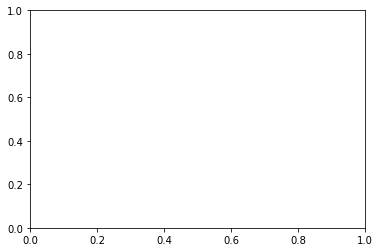

In [189]:
plt.plot(df.year,df.value)

에러의 이유

In [192]:
np.array(df.year)

array(['2016', '2017', '2017', '2017', 2017, 2018, 2018, 2018, 2019, 2019],
      dtype=object)

- 일부는 '2016'와 같이 str형, 일부는 2016와 같은 형태로 되어있다. 

`-` 형태를 바꿔주면 해결할 수 있다. 

In [199]:
np.array(df.year,dtype=np.float64)
# np.array(df.year).astype(np.float64)
# df.year.astype(np.float64)

array([2016., 2017., 2017., 2017., 2017., 2018., 2018., 2018., 2019.,
       2019.])

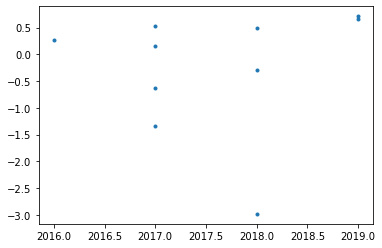

In [202]:
plt.plot(df.year.astype(np.float64),df.value,'.')

`-` 예제2

In [217]:
year = ['2016','2017','2017', '2017년',  2017, 2018, 2018, 2018, 2019, 2019]
value = np.random.randn(10)

In [218]:
df=pd.DataFrame({'year':year, 'value':value})
df

,year,value
0,2016,0.595146
1,2017,0.095543
2,2017,0.794129
3,2017년,-0.488769
4,2017,0.536290
5,2018,-0.529643
6,2018,-0.256575
7,2018,0.783825
8,2019,-0.530932
9,2019,0.864758


In [219]:
df.year.astype(np.float64)

ValueError: could not convert string to float: '2017년'

In [220]:
L(np.array(df.year)).frequency()

{'2016': 1, '2017': 2, '2017년': 1, 2017: 1, 2018: 3, 2019: 2}

- '2016'과 같은 형태, '2017년'과 같은 형태, 숫자형이 혼합.. -> 맞춤형 변환이 필요함

(예비학습)

In [224]:
'2017년'.replace("년","")

'2017'

In [234]:
def f(a): ## 사실 데이터의 구조를 모르면 이런 함수를 짤 수 없음.. -> 구조를 정리한다는 측면에서 freq가 있으면 좋아보인다.
    if type(a) is str:
        if "년" in a:
            return int(a.replace("년",""))
        else: 
            return int(a)
    else:
        return a 

In [235]:
[f(a) for a in arr]

[2016, 2017, 2017, 2017, 2017, 2018, 2018, 2018, 2019, 2019]

In [236]:
df.year = [f(a) for a in arr]

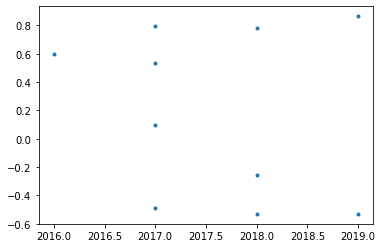

In [237]:
plt.plot(df.year,df.value,'.')

`-` 예전생각: 사용자정의 자료형은 별로 필요가 없다 -> 요즘생각: 어떠한 반복된 일을 계속한다면 사용자 정의 자료형을 잘 개발해 두는것이 유용하다. 